# **Deep Learning – Práctica 25/26**

**Nombre:** Miguel Ángel Valbuena Bueno  
**Curso:** 2025-2026  
**Título del proyecto:** Clasificación de caracteres Kuzushiji mediante redes neuronales profundas  
-----

---
# 2. Entorno experimental y reproducibilidad
---

## 2.1. Librerías

Se presentan el conjunto de librerías utilizadas en esta práctica. Para facilitar la trazabilidad del experimento, se imprimen las versiones de todos los paquetes externos clave (*Deep Learning*, Matemáticas y Visualización).

In [1]:
# =========================================================
# 1. Librerías estándar de Python
# =========================================================
import copy
import os
import random
import shutil
import sys
import time
from collections import Counter

# =========================================================
# 2. Configuración de entorno y rutas (Crítico antes de src)
# =========================================================
BASE_DIR = os.path.abspath("..")
if BASE_DIR not in sys.path:
    sys.path.append(BASE_DIR)

# =========================================================
# 3. Librerías de terceros (Científicas y ML)
# =========================================================
import matplotlib
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from IPython.display import Markdown, display
from PIL import Image, ImageDraw, ImageFont, ImageOps
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)
from torch.utils.data import DataLoader, random_split

# =========================================================
# 4. Importaciones locales (src.utils)
# =========================================================
from src.utils import (
    CNN_ResNet,
    calculate_dataset_statistics,
    cargar_y_validar_kmnist,
    create_image_from_text,
    evaluate_model,
    get_predictions,
    load_checkpoint,
    prepare_dataloaders,
    plot_class_distribution,
    plot_confusion_matrix,
    plot_error_gallery,
    plot_normalized_batch,
    plot_sample_images,
    plot_training_history,
    set_seed,
    setup_environment,
    train_model,
    visualize_ood_confidence
)

# =========================================================
# 5. Configuración de Notebook e Inicialización
# =========================================================
%matplotlib inline

# Verificación de versiones
print("=== Configuración del Entorno ===")
print(f"Python Runtime       : {sys.version.split()[0]}")
print(f"PyTorch Version      : {torch.__version__}")
print(f"Torchvision Version  : {torchvision.__version__}")
print(f"Numpy Version        : {np.__version__}")
print(f"Pandas Version       : {pd.__version__}")
print(f"Matplotlib Version   : {matplotlib.__version__}")
print(f"Seaborn Version      : {sns.__version__}")
print(f"Scikit-learn Version : {sklearn.__version__}")

# Configuración de hardware y reproducibilidad
device, NUM_WORKERS = setup_environment()
g_cpu = set_seed(seed=42)

=== Configuración del Entorno ===
Python Runtime       : 3.12.10
PyTorch Version      : 2.8.0+cu126
Torchvision Version  : 0.23.0+cu126
Numpy Version        : 2.2.6
Pandas Version       : 2.3.3
Matplotlib Version   : 3.10.8
Seaborn Version      : 0.13.2
Scikit-learn Version : 1.7.2

=== Detección de Hardware ===
Núcleos lógicos CPU  : 32
Dispositivo          : GPU (NVIDIA GeForce RTX 4060)
VRAM Disponible      : 8.00 GB
Configuración OS     : Windows (num_workers=0)

Semilla global y generador fijados en: 42


In [2]:
BASE_DIR = os.path.abspath("..")
if BASE_DIR not in sys.path:
    sys.path.append(BASE_DIR)

print(BASE_DIR)

d:\ProyectosPython\Master_deep_learning_python\A13_MLOps\PracticaFinal


In [3]:
# Ejecución de la configuración
device, NUM_WORKERS = setup_environment()

print("-" * 60)
print(f"Configuración Lista -> Device: {device} | Workers: {NUM_WORKERS}")


=== Detección de Hardware ===
Núcleos lógicos CPU  : 32
Dispositivo          : GPU (NVIDIA GeForce RTX 4060)
VRAM Disponible      : 8.00 GB
Configuración OS     : Windows (num_workers=0)
------------------------------------------------------------
Configuración Lista -> Device: cuda | Workers: 0


## 2.3. Control de aleatoriedad

Para mejorar la reproducibilidad y reducir la variabilidad entre ejecuciones, se fija una semilla global en todas las librerías estocásticas (`numpy`, `random`, `torch`) y se instancia un generador específico (`g_cpu`) para las particiones de datos.

In [4]:
# Generador para reproducibilidad en DataLoaders
g_cpu = set_seed()


Semilla global y generador fijados en: 42


---
# 3. Dataset y exploración inicial
---

## 3.1. Descripción del dataset KMNIST

El conjunto de datos seleccionado es **Kuzushiji-MNIST (KMNIST)**. Se trata de un dataset de clasificación multiclase diseñado como sustituto directo (*drop-in replacement*) del MNIST original, manteniendo sus dimensiones y equilibrio, pero presentando una mayor complejidad en el reconocimiento visual debido a la naturaleza cursiva de los caracteres.

* **Contenido:** 70,000 imágenes en escala de grises de 28x28 píxeles.
* **Clases:** 10 categorías correspondientes a caracteres del silabario **Hiragana** en su forma antigua (*Kuzushiji*).
* **Distribución:** El conjunto está perfectamente balanceado por diseño, con 6,000 muestras por clase en entrenamiento y 1,000 en test.

| Conjunto | N.º Muestras | Dimensión Tensorial (C,H,W) | Etiquetas |
|:---|:---|:---|:---|
| **Train** | 60,000 | $(1, 28, 28)$ | 10 clases |
| **Test** | 10,000 | $(1, 28, 28)$ | 10 clases |

## 3.2. Carga e integridad dimensional

En esta sección se realiza la carga del dataset y se verifica la integridad estructural de los datos. El objetivo es garantizar que las muestras cumplen el formato esperado por las capas convolucionales `Conv2d` de PyTorch: un tensor tridimensional con el orden estándar $[Canales, Altura, Anchura]$.

Dado que KMNIST es un dataset homogéneo por construcción, validamos una muestra representativa mediante *assertions* para asegurar que las imágenes tienen la forma $(1, 28, 28)$ antes de proceder al modelado.

In [5]:
# Definición de la ruta base hacia el directorio de datos
ruta_base = '../data'

# Carga de la partición de entrenamiento (solo ToTensor, sin normalización)
# La normalización se aplica en la sección 4.1, una vez calculadas las
# estadísticas descriptivas sobre este mismo conjunto.
ds_train = cargar_y_validar_kmnist(data_path=ruta_base, is_train=True, download=False)

# Carga de la partición de prueba
ds_test = cargar_y_validar_kmnist(data_path=ruta_base, is_train=False, download=False)

Verificando directorio: D:\ProyectosPython\Master_deep_learning_python\A13_MLOps\PracticaFinal\data\KMNIST\raw
Archivos de origen detectados y validados por nomenclatura.
Iniciando procesamiento de KMNIST (train=True)...

=== Verificación dimensional ===
Formato del tensor  : torch.Size([1, 28, 28])
Rango de valores    : [0.0000, 1.0000]
Dataset cargado, instanciado y verificado correctamente.
Verificando directorio: D:\ProyectosPython\Master_deep_learning_python\A13_MLOps\PracticaFinal\data\KMNIST\raw
Archivos de origen detectados y validados por nomenclatura.
Iniciando procesamiento de KMNIST (train=False)...

=== Verificación dimensional ===
Formato del tensor  : torch.Size([1, 28, 28])
Rango de valores    : [0.0000, 1.0000]
Dataset cargado, instanciado y verificado correctamente.


## 3.3.

=== Estadísticas Globales del Dataset (Train) ===
Media (Mean)             : 0.1918
Desviación Estándar (Std): 0.3483


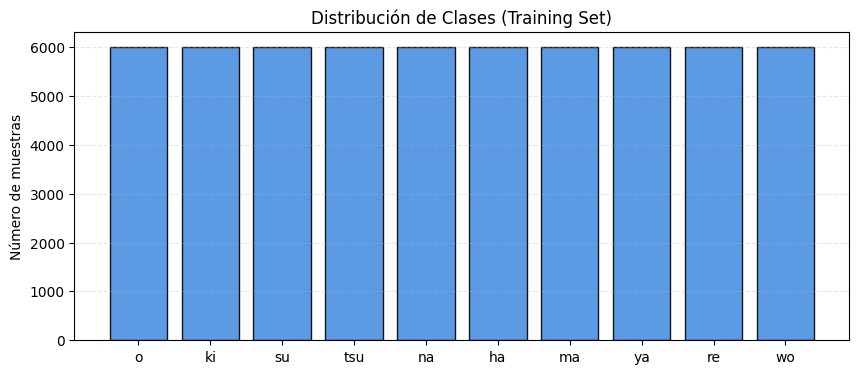


Muestras visuales del dataset (KMNIST):


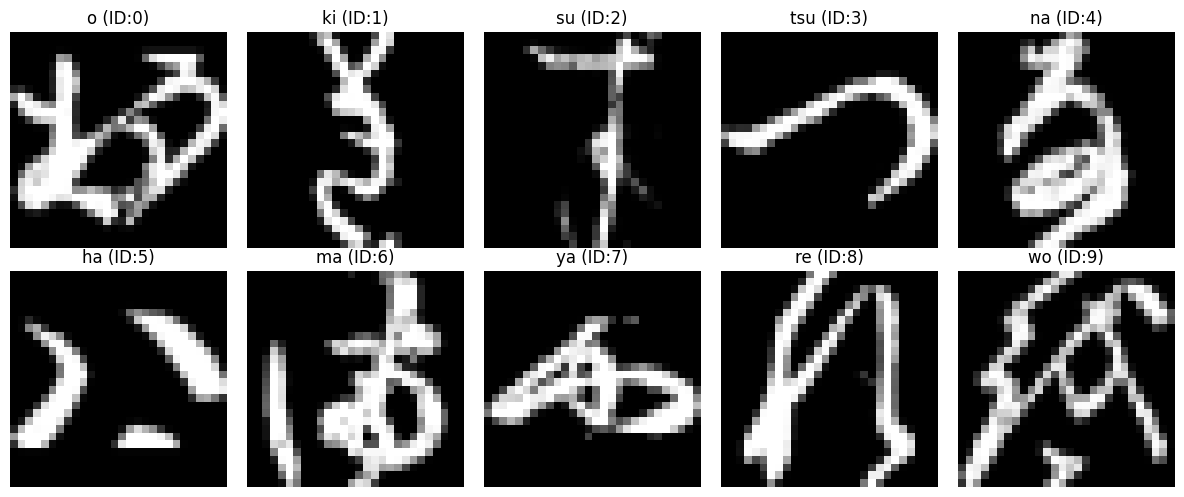

In [6]:
# Cálculo de estadísticas descriptivas
mean_val, std_val = calculate_dataset_statistics(ds_train)

print("=== Estadísticas Globales del Dataset (Train) ===")
print(f"Media (Mean)             : {mean_val:.4f}")
print(f"Desviación Estándar (Std): {std_val:.4f}")

# Definición de clases para KMNIST
labels_map = {
    0: "o", 1: "ki", 2: "su", 3: "tsu", 4: "na",
    5: "ha", 6: "ma", 7: "ya", 8: "re", 9: "wo"
}

# Visualización de distribución de frecuencias
plot_class_distribution(targets=ds_train.targets.tolist(), labels_map=labels_map)

# Visualización de muestras por clase
print("\nMuestras visuales del dataset (KMNIST):")
plot_sample_images(dataset=ds_train, labels_map=labels_map)

---
# 4. Preprocesado y preparación de los datos
---

In [7]:
# Configuración de métricas de normalización (procedentes del análisis EDA)
if 'mean_val' not in locals() or 'std_val' not in locals():
    mean_val, std_val = 0.1918, 0.3483
    print("Advertencia: Usando valores estadísticos precalculados (Fallback).")

print(f"Configuración de Normalización -> Media: {mean_val:.4f}, Std: {std_val:.4f}")

# Configuración de Hiperparámetros de Carga
BATCH_SIZE_BASELINE = 8
BATCH_SIZE_EVAL = 64

# Creación unificada de DataLoaders con prevención de filtración de transformaciones
(train_loader, val_loader, test_loader, 
 train_sz, val_sz, test_sz) = prepare_dataloaders(
    ruta_base=ruta_base,
    mean_val=mean_val,
    std_val=std_val,
    batch_size_train=BATCH_SIZE_BASELINE,
    batch_size_eval=BATCH_SIZE_EVAL,
    num_workers=NUM_WORKERS,
    generator=g_cpu
)

print("\n=== Resumen del Particionado ===")
print(f"Conjunto de Entrenamiento : {train_sz:,} muestras")
print(f"Conjunto de Validación    : {val_sz:,} muestras")
print(f"Conjunto de Test (Fijo)   : {test_sz:,} muestras")

Configuración de Normalización -> Media: 0.1918, Std: 0.3483

=== Resumen del Particionado ===
Conjunto de Entrenamiento : 48,000 muestras
Conjunto de Validación    : 12,000 muestras
Conjunto de Test (Fijo)   : 10,000 muestras


# 5. Instanciación del Modelo y Configuración del Optimizador

In [8]:
# 1. Instanciación de la arquitectura validada
model_final = CNN_ResNet().to(device)

# 2. Configuración de parámetros de regularización
MAX_EPOCHS_OPT = 200
INITIAL_LR = 0.001
L2_REGULARIZATION = 1e-4

criterion = nn.CrossEntropyLoss()

# 3. Aplicación de Weight Decay (L2) sobre Adam
optimizer = optim.Adam(
    model_final.parameters(), 
    lr=INITIAL_LR, 
    weight_decay=L2_REGULARIZATION
)

# 4. Planificador de reducción dinámica
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=0.1, 
    patience=5
)

print("=== Configuración de Arquitectura y Optimizador ===")
print(f"Arquitectura : CNN_ResNet ({sum(p.numel() for p in model_final.parameters()):,} parámetros)")
print(f"Optimizador  : Adam (LR inicial={INITIAL_LR}, L2={L2_REGULARIZATION})")
print(f"Planificador : ReduceLROnPlateau (Factor=0.1, Paciencia=3 épocas)")
print(f"Épocas max.  : {MAX_EPOCHS_OPT}")

=== Configuración de Arquitectura y Optimizador ===
Arquitectura : CNN_ResNet (174,970 parámetros)
Optimizador  : Adam (LR inicial=0.001, L2=0.0001)
Planificador : ReduceLROnPlateau (Factor=0.1, Paciencia=3 épocas)
Épocas max.  : 200


# 6. Gestión de Checkpoints y Entrenamiento Estructurado

In [9]:
# Configuración del entorno de guardado
SAVE_DIR_CNN = "../models"
os.makedirs(SAVE_DIR_CNN, exist_ok=True)
CHECKPOINT_NAME = "ResNet_Final_Combined.pth"
SAVE_PATH = os.path.join(SAVE_DIR_CNN, CHECKPOINT_NAME)

TRAIN_FORCE_FINAL = False
train_final_flag = True

if os.path.exists(SAVE_PATH) and not TRAIN_FORCE_FINAL:
    print(f"--> Archivo previo detectado: {SAVE_PATH}")
    success, best_model_wts, metrics = load_checkpoint(SAVE_PATH, model_final, device)
    
    if success:
        saved_loss = metrics.get('val_loss', float('inf'))
        saved_acc = metrics.get('val_acc', 0.0)
        print(f"    Métricas recuperadas -> Val Loss: {saved_loss:.4f} | Val Acc: {saved_acc:.4f}")
        print("    Carga exitosa. Saltando entrenamiento.")
        train_final_flag = False

if train_final_flag:
    if torch.cuda.is_available(): 
        torch.cuda.empty_cache()

    print("\nIniciando Entrenamiento Final...")
    # Se delega el procesamiento al pipeline en utils.py
    history, model_final = train_model(
        model=model_final,
        train_loader=train_loader, # DataLoader originado en la etapa de preprocesamiento (Data Augmentation)
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        num_epochs=MAX_EPOCHS_OPT,
        device=device,
        scheduler=scheduler
    )
    
    # Persistencia del modelo tras el entrenamiento completo
    torch.save({
        'model_state_dict': model_final.state_dict(),
        'metrics': {'val_acc': history['val_acc'][-1], 'val_loss': history['val_loss'][-1]}
    }, SAVE_PATH)

--> Archivo previo detectado: ../models\ResNet_Final_Combined.pth
    Métricas recuperadas -> Val Loss: 0.0002 | Val Acc: 1.0000
    Carga exitosa. Saltando entrenamiento.


# 7. Evaluación de Rendimiento (Test Set)

In [10]:
print("\n" + "="*60)
print("EVALUACIÓN FINAL DEL EXPERIMENTO (TEST SET)")
print("="*60)

BASELINE_ACC = 0.9862 # Umbral de control establecido

# Inferencia centralizada
test_acc_final, test_f1_final = evaluate_model(model_final, test_loader, device)
diff = test_acc_final - BASELINE_ACC

final_lr = optimizer.param_groups[0]['lr']

print(f"Learning Rate Final        : {final_lr:.1e}")
print(f"Referencia (Línea base)    : {BASELINE_ACC:.4f}")
print(f"Modelo Final (ResNet-Opt)  : {test_acc_final:.4f}")
print("-" * 40)

if diff > 0:
    print(f"[+] Mejora observada: +{diff:.4f}")
    print(f"   -> Acc: {test_acc_final:.4f} | F1: {test_f1_final:.4f}")
elif diff < 0:
    print(f"[-] Disminución de rendimiento: {diff:.4f}")
    print("   -> Hipótesis: Posible sobre-regularización o varianza en el conjunto de prueba. [NO VERIFICABLE]")
else:
    print(f"[=] Rendimiento idéntico: ({diff:.4f}).")
print("="*60)


EVALUACIÓN FINAL DEL EXPERIMENTO (TEST SET)
Learning Rate Final        : 1.0e-03
Referencia (Línea base)    : 0.9862
Modelo Final (ResNet-Opt)  : 0.9893
----------------------------------------
[+] Mejora observada: +0.0031
   -> Acc: 0.9893 | F1: 0.9893


# 8. Auditoría de Rendimiento Global

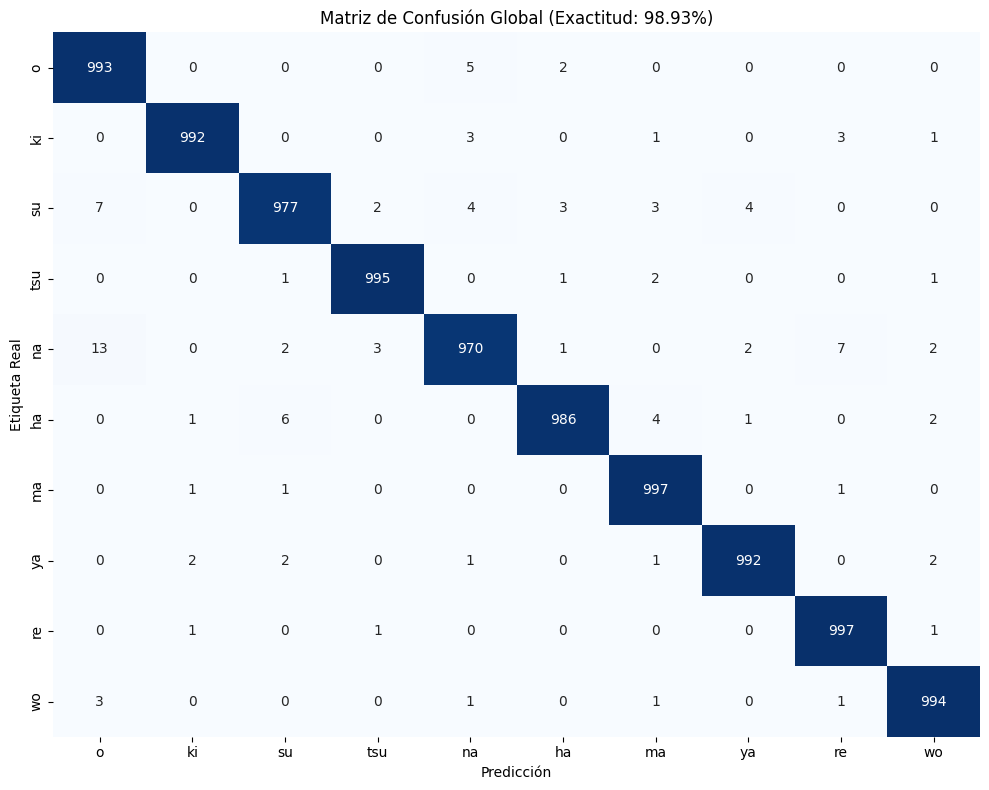

In [11]:
# 1. Visualización de la dinámica de convergencia
# Asume que la variable 'history' fue retenida en el entorno desde el paso de entrenamiento
if 'history' in locals():
    plot_training_history(history)

# Definición de mapeo de clases para evaluación cualitativa
class_names = ['o', 'ki', 'su', 'tsu', 'na', 'ha', 'ma', 'ya', 're', 'wo']

# 2. Extracción de predicciones exhaustivas
y_true, y_pred, y_probs, images_test = get_predictions(model_final, test_loader, device)

# 3. Matriz de confusión
plot_confusion_matrix(y_true, y_pred, class_names)

# 9. Análisis Cualitativo de Casos Límite


=== Galería de Errores de Clasificación ===


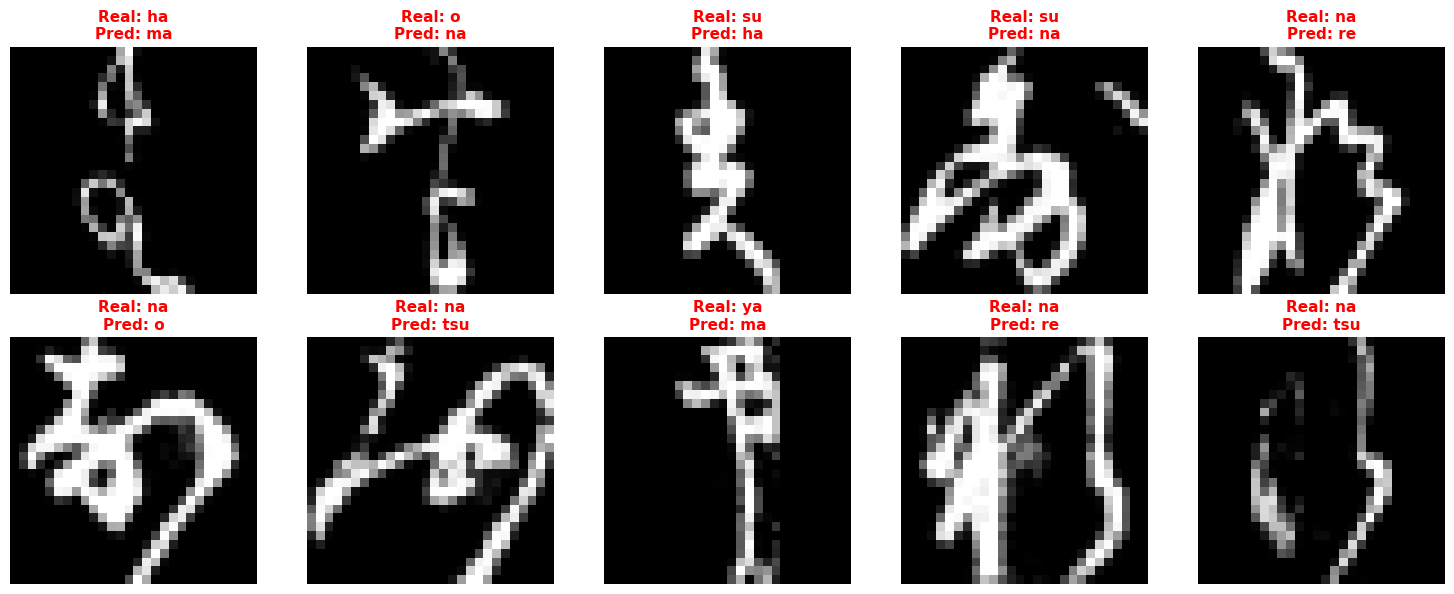

In [12]:
# Despliegue de imágenes donde el modelo difiere de la anotación real
print("\n=== Galería de Errores de Clasificación ===")
plot_error_gallery(images_test, y_true, y_pred, class_names, num_images=10)

# 10. Evaluación de Robustez (Out-of-Distribution Testing)


=== Evaluación de Robustez ante Datos Sintéticos (OOD) ===


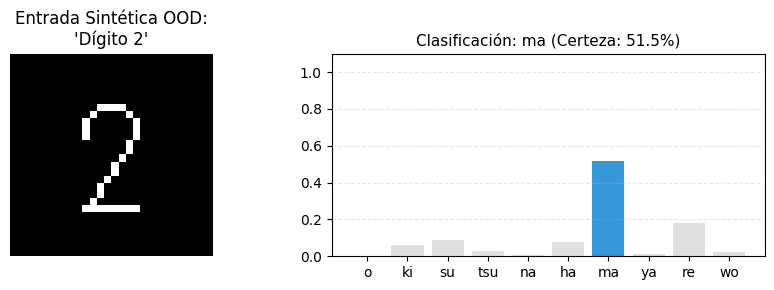

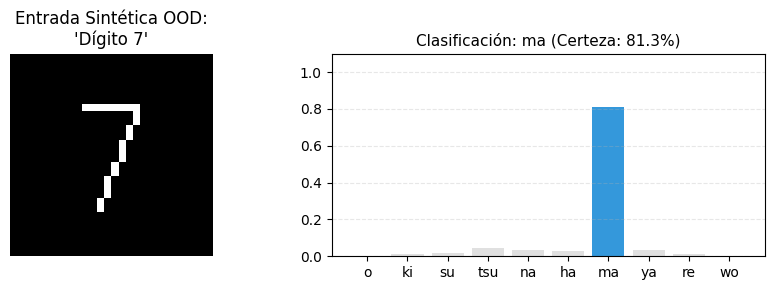

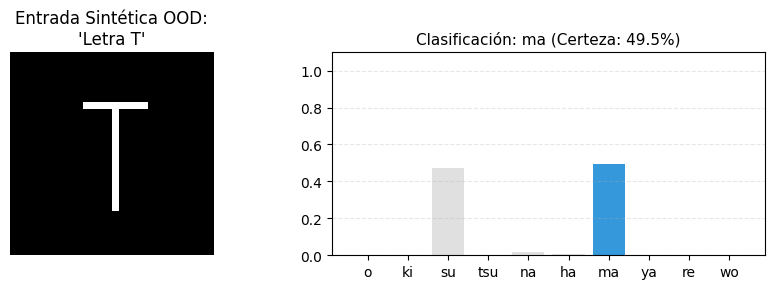

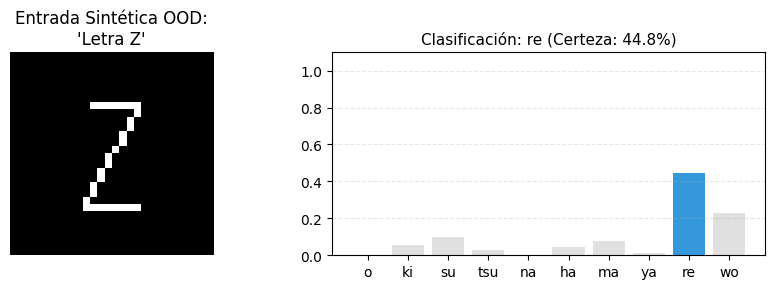

In [13]:
print("\n=== Evaluación de Robustez ante Datos Sintéticos (OOD) ===")

ood_tests = [
    ('Dígito 2', '2'),  
    ('Dígito 7', '7'),  
    ('Letra T', 'T'),
    ('Letra Z', 'Z')
]

for label, char_str in ood_tests:
    try:
        # Requiere los estadísticos calculados en las primeras etapas
        tensor_ood = create_image_from_text(char_str, mean_val, std_val)
        visualize_ood_confidence(model_final, tensor_ood, label, class_names, device)
    except Exception as e:
        print(f"No se pudo procesar la prueba para '{label}': {e}")